IMPORT GOLD STANDARD TRANSCRIPTS

In [2]:
import requests
#SERVER_URL = "http://127.0.0.1:8008"
SERVER_URL = "http://192.168.2.239"
# gather the podcast slug, episode guid, and audio file link for transcription
podcasts = requests.get(f"{SERVER_URL}/api/podcasts/")
podcasts = podcasts.json()
for i, p in enumerate(podcasts):
    print(f"{i}: {p['title']} ({p['slug']})")

0: Verdict with Ted Cruz (verdict-with-ted-cruz)
1: Leger om livet (leger-om-livet)
2: Norsken, svensken og dansken (norsken-svensken-og-dansken)
3: Huberman Lab (huberman-lab)
4: The Ben Shapiro Show (the-ben-shapiro-show)
5: The Megyn Kelly Show (the-megyn-kelly-show)
6: The Daily (the-daily)
7: Checks and Balance from The Economist (checks-and-balance-from-the-economist)
8: Pod Save America (pod-save-america)
9: Logbuch:Netzpolitik (logbuchnetzpolitik)
10: Apokalypse & Filterkaffee (apokalypse-filterkaffee)
11: Lage der Nation - der Politik-Podcast aus Berlin (lage-der-nation-der-politik-podcast-aus-berlin)
12: Inside Europe | Deutsche Welle (inside-europe-deutsche-welle)
13: Forklart (forklart)
14: Oppdatert (oppdatert)
15: USApodden (usapodden)
16: Det Store Bildet (det-store-bildet)
17: Best of the Left - Progressive Politics and Culture, Curated by Humans, Not Algorithms (best-of-the-left-progressive-politics-and-culture)
18: Gaslit Nation with Andrea Chalupa and Sarah Kendzior 

### Add transcriptions from files that have the episode guid as the filename (.txt as extension)

In [ ]:
# loop through all the files in the "lrntech transcripts" folder
# and print the file name for each file without the ".txt" extension
import os


path = "lrntech transcripts"
for file in os.listdir(path):
    print(file)
    transcription_dict = {}
    transcription_dict["name"] = "lorn.tech"
    transcription_dict["words"] = ""
    transcription_dict["speech2txt"] = ""
    transcription_dict["runtime"] = "00:00:00"
    transcription_dict["created"] = "2023-06-01T00:00"
    transcription_dict["language"] = "no"
    transcription_dict["diarization"] = ""
    transcription_dict["guid"] = file[:-4]
    with open(f"{path}/{file}", "r") as f:
        transcription_dict["text"] = f.read()

    #print(transcription_dict)
    

    #post transcription to api
    #res = requests.post(f"{SERVER_URL}/api/transcriptions/", json=transcription_dict)
    #print(res.status_code)




In [ ]:
transcription_dict

## Analyze LØRN

In [2]:
import requests
#SERVER_URL = "http://127.0.0.1:8008"
SERVER_URL = "http://192.168.2.239"
# gather the podcast slug, episode guid, and audio file link for transcription
podcasts = requests.get(f"{SERVER_URL}/api/podcasts/")
podcasts = podcasts.json()
for i, p in enumerate(podcasts):
    print(f"{i}: {p['title']} ({p['slug']})")

0: Verdict with Ted Cruz (verdict-with-ted-cruz)
1: Leger om livet (leger-om-livet)
2: Norsken, svensken og dansken (norsken-svensken-og-dansken)
3: Huberman Lab (huberman-lab)
4: The Ben Shapiro Show (the-ben-shapiro-show)
5: The Megyn Kelly Show (the-megyn-kelly-show)
6: The Daily (the-daily)
7: Checks and Balance from The Economist (checks-and-balance-from-the-economist)
8: Pod Save America (pod-save-america)
9: Logbuch:Netzpolitik (logbuchnetzpolitik)
10: Apokalypse & Filterkaffee (apokalypse-filterkaffee)
11: Lage der Nation - der Politik-Podcast aus Berlin (lage-der-nation-der-politik-podcast-aus-berlin)
12: Inside Europe | Deutsche Welle (inside-europe-deutsche-welle)
13: Forklart (forklart)
14: Oppdatert (oppdatert)
15: USApodden (usapodden)
16: Det Store Bildet (det-store-bildet)
17: Best of the Left - Progressive Politics and Culture, Curated by Humans, Not Algorithms (best-of-the-left-progressive-politics-and-culture)
18: Gaslit Nation with Andrea Chalupa and Sarah Kendzior 

In [3]:
podcast = podcasts[36]

In [4]:
from jiwer import wer
from whisper.normalizers import BasicTextNormalizer
whisper_normalizer = BasicTextNormalizer()
                              
eps = []

for ep in podcast["audioitem_set"]:
    gs = None

    for script in ep["transcription_set"]:
        if script["name"] == "lorn.tech":
            res = requests.get(f"{SERVER_URL}/api/transcriptions/{script['uuid']}/")
            gs = res.json()['text']
            break
    
    if gs:
        for script in ep["transcription_set"]:
            if script["name"] != "lorn.tech":
                res = requests.get(f"{SERVER_URL}/api/transcriptions/{script['uuid']}/")
                model_output = res.json()['text']
                wer_score = wer(whisper_normalizer(gs), whisper_normalizer(model_output))
                print(f"{ep['title']} ({script['name']}): {wer_score}")
                eps.append((ep['title'], script['name'], wer_score))

        #print(ep["title"])
        #res = requests.get(f"{SERVER_URL}/api/transcriptions/{script['uuid']}/")
        #print(res.status_code)
        #print(res.json()['text'])


#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (Whisper-large): 0.21382903149419843
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (Whisper-medium): 0.24745441629173573
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (scream-sm-apr-beta): 0.3916646933459626
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (Whisper-small): 0.31588917830925883
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (Whisper-base): 0.5036703765095903
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (scream-med-beta): 0.6215960217854606
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (scream-med-beta): 0.6507222353776936
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (scream-med-beta): 0.6064409187781198
#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak (scream-med-beta): 0.322045938905991
#C1387_230526

In [28]:
new_eps = []
current_ep = None
med_found = False
for ep in eps:
    if current_ep != ep[0]:
        current_ep = ep[0]
        new_eps.append(ep)
    elif ep[1] == "Whisper-small":
        new_eps.append(ep)
    elif ep[1] == "Whisper-medium" and not med_found:
        new_eps.append(ep)
        med_found = True
    elif ep[1] == "Whisper-medium" and med_found:
        new_eps.append([ep[0], ep[1]+"-prompted", ep[2]])
    



In [29]:
new_eps

[('#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak',
  'Whisper-large',
  0.21382903149419843),
 ('#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak',
  'Whisper-medium',
  0.24745441629173573),
 ('#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak',
  'Whisper-small',
  0.31588917830925883),
 ['#C1387_230526_Miloš Novović og Frode Skaarnes: Risikoreduserende tiltak',
  'Whisper-medium-prompted',
  0.24958560265214302],
 ('#C1386_230516_Miloš Novović og Frode Skaarnes: Risikovurdering',
  'Whisper-large',
  0.1968408262454435),
 ['#C1386_230516_Miloš Novović og Frode Skaarnes: Risikovurdering',
  'Whisper-medium-prompted',
  0.20868772782503037],
 ('#C1386_230516_Miloš Novović og Frode Skaarnes: Risikovurdering',
  'Whisper-small',
  0.2773390036452005),
 ['#C1386_230516_Miloš Novović og Frode Skaarnes: Risikovurdering',
  'Whisper-medium-prompted',
  0.2026123936816525],
 ('#C1385_230516_Miloš Novović og Frode Skaarnes

In [30]:
import pandas as pd
eps_df = pd.DataFrame(new_eps, columns=["Episode", "Model", "WER"])

In [31]:
eps_df

,Episode,Model,WER
0,#C1387_230526_Miloš Novović og Frode Skaarnes:...,Whisper-large,0.213829
1,#C1387_230526_Miloš Novović og Frode Skaarnes:...,Whisper-medium,0.247454
2,#C1387_230526_Miloš Novović og Frode Skaarnes:...,Whisper-small,0.315889
3,#C1387_230526_Miloš Novović og Frode Skaarnes:...,Whisper-medium-prompted,0.249586
4,#C1386_230516_Miloš Novović og Frode Skaarnes:...,Whisper-large,0.196841
...,...,...,...
227,M0064c_230217_Hege Hammersland: Bærekraftig ha...,Whisper-medium-prompted,0.232700
228,M0064a_230217_Hege Hammersland: Bærekraftig ha...,Whisper-large,0.221239
229,M0064a_230217_Hege Hammersland: Bærekraftig ha...,Whisper-medium-prompted,0.247586
230,M0064a_230217_Hege Hammersland: Bærekraftig ha...,Whisper-small,0.340909


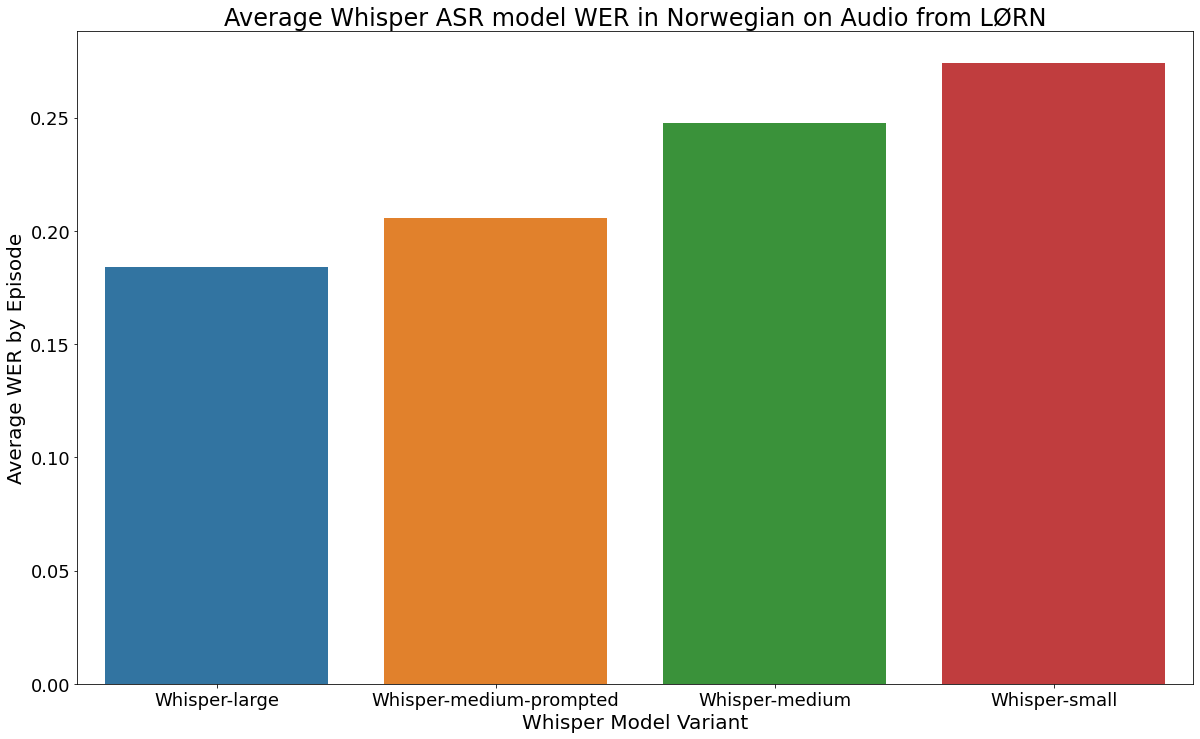

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# First group by Model and calculate the mean of WER
grouped_df = eps_df.groupby("Model")["WER"].mean().reset_index()

# Sort the DataFrame by WER
grouped_df = grouped_df.sort_values(by="WER")

# Use seaborn to create the bar plot
plt.figure(figsize=(20,12))
sns.barplot(x="Model", y="WER", data=grouped_df)

plt.title("Average Whisper ASR model WER in Norwegian on Audio from LØRN", fontsize=24)
plt.xlabel("Whisper Model Variant", fontsize=20)
plt.ylabel("Average WER by Episode", fontsize=20)
# increase the size of the axis labels
plt.tick_params(axis='both', which='major', labelsize=18)
plt.show()

Analyze WER from crowdsourcer annotations

In [ ]:
import pandas as pd
# import "transcription annotations.csv" to a dataframe
df = pd.read_csv("transcription annotations.csv")
df

In [ ]:
# get the text field from index 0 of the dataframe
df.iloc[0]['text']

In [ ]:
df.iloc[0]['edit']

In [ ]:
from jiwer import wer
wer(df.iloc[0]['text'], df.iloc[0]['edit'])

In [ ]:
wer_dict = {}

In [ ]:
import requests

PORT = 8008
SERVER = "http://127.0.0.1"

podcasts = requests.get(f"{SERVER}:{PORT}/api/podcasts/")
podcasts = podcasts.json()

In [ ]:
from jiwer import wer

for podcast in podcasts:
    slug = podcast['slug']
    #if slug != pod_slug:
    #    continue
    for audioitem in podcast['audioitem_set']:
        #if audioitem['guid'] not in guids:
        #    continue
        ep_guid = audioitem['guid']
        for transcription in audioitem['transcription_set']:
            trans_uuid = transcription['uuid']
            for segmentation in transcription['segmentation_set']:
                #if segmentation["uuid"] != "001a6f98-f59e-11ed-a982-00155d36ecb3":
                #    continue
                if segmentation['name'] == "Medical TR/DI/AD" or segmentation['name'] == "ProlificP TR/DI/AD" or segmentation['name'] == "Pv3 TR/DI/AD":
                    reference_texts = []
                    hypothesis_texts = []
                    seg_uuid = segmentation['uuid']
                    # retrieve full transcript from API
                    seg = requests.get(f"{SERVER}:{PORT}/api/segmentations/{seg_uuid}/")
                    seg = seg.json()
                    for utterance in seg['utterance_set']:
                        # check if utterance["classification_set"] contains any records with qualifier="Transcription"
                        if any(classification["qualifier"] == "Transcription" for classification in utterance["classification_set"]):
                            # loop over the classifications with qualifier="Transcription"
                            for classification in utterance["classification_set"]:
                                if classification["qualifier"] == "Transcription":
                                    if classification["category"] == "Approve Original":
                                        hypothesis_texts.append(utterance["text"])
                                        reference_texts.append(utterance["text"])
                                    # otherwise check if the category string contains "edit"
                                    elif classification["category"] == "Edit" or classification["category"] == "Confirm Edit":
                                        # if so, add the text to hypothesis_texts
                                        hypothesis_texts.append(classification["label"])
                                        reference_texts.append(utterance["text"])
                                        
                    # calculate WER
                    if len(reference_texts) > 0 and len(reference_texts) == len(hypothesis_texts):
                        print(len(hypothesis_texts),  len(reference_texts))
                        word_error_rate = wer(reference_texts, hypothesis_texts)
                        if word_error_rate * 100 > 1:
                            wer_dict[seg_uuid + " " + podcast["title"] + " " + audioitem["title"]]  = wer(reference_texts, hypothesis_texts)


In [ ]:
wer_dict

In [ ]:
for i, text in enumerate(reference_texts):
    if text != hypothesis_texts[i]:
        print(text, hypothesis_texts[i])